In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import re



# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
# Parse results from result.txt
def parse_results(file_path='result.txt'):
    """Parse experimental results from result.txt file"""
    
    with open(file_path, 'r') as f:
        content = f.read()
    
    # Pattern to match test results
    pattern = r'Number of Nodes: (\d+), Number of Miners: (\d+), Number of transaction: (\d+)'
    
    results = []
    sections = content.split('Number of Nodes:')
    
    for section in sections[1:]:  # Skip first empty section
        lines = section.strip().split('\n')
        if len(lines) < 5:
            continue
            
        # Extract network info
        first_line = lines[0]
        
        match = re.search(r'(\d+),.*?Miners: (\d+),.*?transaction: (\d+)', first_line)
        if not match:
            continue
            
        num_nodes = int(match.group(1))
        num_miners = int(match.group(2))
        num_tx = int(match.group(3))
        
        # Parse algorithm results
        for i, line in enumerate(lines):
            if 'Algorithm' in line and 'Throughput' in line:
                # Next lines contain data
                for j in range(i+2, len(lines)):
                    if '---' in lines[j] or not lines[j].strip():
                        break
                    parts = lines[j].split()
                    if len(parts) >= 5:
                        algo = parts[0]
                        try:
                            throughput = float(parts[1])
                            latency = float(parts[2])
                            cpu = float(parts[3])
                            memory = float(parts[4])
                            
                            results.append({
                                'nodes': num_nodes,
                                'miners': num_miners,
                                'transactions': num_tx,
                                'algorithm': algo,
                                'throughput': throughput,
                                'latency': latency,
                                'cpu_usage': cpu,
                                'memory_usage': memory
                            })
                        except (ValueError, IndexError):
                            continue
    
    return pd.DataFrame(results)

# Load data
df = parse_results('result.txt')
print(f"Total records: {len(df)}")
print(f"\nAlgorithms found: {df['algorithm'].unique()}")
print(f"\nNetwork sizes: {sorted(df['nodes'].unique())}")
print(f"\nSample data:")
print(df.head(10))

Total records: 46

Algorithms found: ['AASC' 'PoEM' 'POS' 'POCH' 'mAASC']

Network sizes: [np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(70), np.int64(100)]

Sample data:
   nodes  miners  transactions algorithm  throughput    latency  cpu_usage  \
0     10       2           500      AASC    0.529869   1.887260        6.1   
1     10       2           500      PoEM    0.996298   1.003720       69.6   
2     10       2           500       POS    2.310020   0.432897      153.5   
3     20       4           500      AASC    2.642810   0.378385      133.4   
4     20       4           500      PoEM    0.407770   2.452360      316.5   
5     20       4           500       POS    0.492440   2.030700      171.4   
6     30       6           500      AASC    1.394330   0.717192      148.5   
7     30       6           500      PoEM    0.091477  10.931800      339.3   
8     30       6           500       POS    0.208227   4.802460      200.9   
9     40       8

In [3]:
# Filter data for main comparison (focusing on 100 transaction tests for consistency)
df_main = df[df['transactions'] == 100].copy()

# Also keep 500 transaction tests for separate analysis
df_500 = df[df['transactions'] == 500].copy()

# Group by nodes and algorithm to get averages for mAASC (multiple runs)
df_main = df_main.groupby(['nodes', 'miners', 'algorithm']).agg({
    'throughput': 'mean',
    'latency': 'mean',
    'cpu_usage': 'mean',
    'memory_usage': 'mean'
}).reset_index()

print("Main dataset (100 transactions):")
print(f"Records: {len(df_main)}")
print(f"\nNetwork configurations:")
print(df_main[['nodes', 'miners']].drop_duplicates().sort_values('nodes'))
print(f"\nAlgorithms per network size:")
print(df_main.groupby('nodes')['algorithm'].apply(list))

Main dataset (100 transactions):
Records: 30

Network configurations:
    nodes  miners
0      20      10
5      30      10
10     40      10
15     50      10
20     70      14
25    100      20

Algorithms per network size:
nodes
20     [AASC, POCH, POS, PoEM, mAASC]
30     [AASC, POCH, POS, PoEM, mAASC]
40     [AASC, POCH, POS, PoEM, mAASC]
50     [AASC, POCH, POS, PoEM, mAASC]
70     [AASC, POCH, POS, PoEM, mAASC]
100    [AASC, POCH, POS, PoEM, mAASC]
Name: algorithm, dtype: object


## 1. Throughput Analysis

Throughput measures the number of transactions processed per second. Higher is better.

In [4]:
# Prepare throughput data
throughput_data = df_main[df_main['nodes'].isin([20, 30, 40, 50, 70, 100])].copy()

# Create pivot table for easier plotting
throughput_pivot = throughput_data.pivot_table(
    index='nodes',
    columns='algorithm',
    values='throughput',
    aggfunc='mean'
).fillna(0)

# Sort by nodes
throughput_pivot = throughput_pivot.sort_index()

print("Throughput (transactions/second) by Network Size:")
print(throughput_pivot.round(4))

# Calculate statistics
print("\n=== Throughput Statistics ===")
for algo in ['AASC', 'POS', 'POCH', 'PoEM', 'mAASC']:
    if algo in throughput_pivot.columns:
        values = throughput_pivot[algo].values
        values = values[values > 0]  # Remove zeros
        if len(values) > 0:
            print(f"\n{algo}:")
            print(f"  Mean: {np.mean(values):.4f} tx/s")
            print(f"  Median: {np.median(values):.4f} tx/s")
            print(f"  Max: {np.max(values):.4f} tx/s (at {throughput_pivot.index[np.argmax(values)]} nodes)")
            print(f"  Min: {np.min(values):.4f} tx/s (at {throughput_pivot.index[np.argmin(values)]} nodes)")

Throughput (transactions/second) by Network Size:
algorithm    AASC    POCH     POS    PoEM   mAASC
nodes                                            
20         2.4283  0.6868  0.5494  0.3294  0.6559
30         0.8077  0.3191  0.1976  0.1015  0.2862
40         0.5601  0.2123  0.1506  0.0693  0.2123
50         0.4022  0.1767  0.1126  0.0527  0.1909
70         0.2520  0.1251  0.0825  0.0393  0.1272
100        0.1173  0.0828  0.0551  0.0209  0.0780

=== Throughput Statistics ===

AASC:
  Mean: 0.7612 tx/s
  Median: 0.4812 tx/s
  Max: 2.4283 tx/s (at 20 nodes)
  Min: 0.1173 tx/s (at 100 nodes)

POS:
  Mean: 0.1913 tx/s
  Median: 0.1316 tx/s
  Max: 0.5494 tx/s (at 20 nodes)
  Min: 0.0551 tx/s (at 100 nodes)

POCH:
  Mean: 0.2671 tx/s
  Median: 0.1945 tx/s
  Max: 0.6868 tx/s (at 20 nodes)
  Min: 0.0828 tx/s (at 100 nodes)

PoEM:
  Mean: 0.1022 tx/s
  Median: 0.0610 tx/s
  Max: 0.3294 tx/s (at 20 nodes)
  Min: 0.0209 tx/s (at 100 nodes)

mAASC:
  Mean: 0.2584 tx/s
  Median: 0.2016 tx/s
  Max:

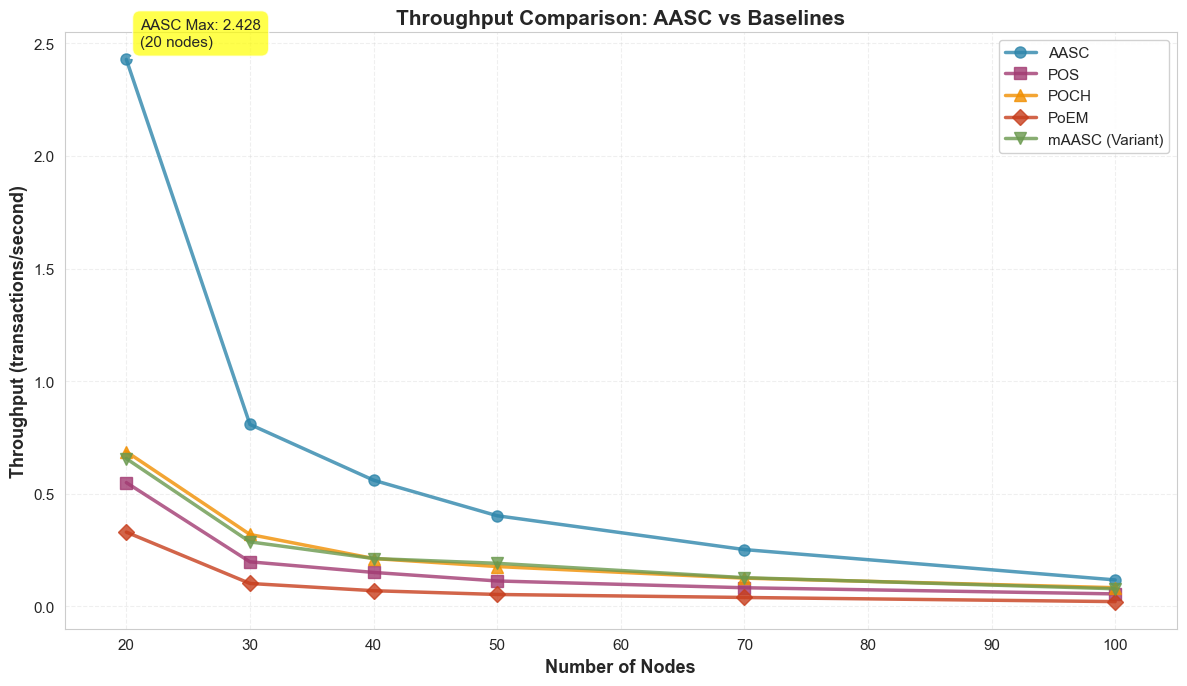

Figure saved to images/throughput_aasc.png


In [5]:
# Plot Throughput Comparison
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each algorithm
markers = {'AASC': 'o', 'POS': 's', 'POCH': '^', 'PoEM': 'D', 'mAASC': 'v'}
colors = {'AASC': '#2E86AB', 'POS': '#A23B72', 'POCH': '#F18F01', 'PoEM': '#C73E1D', 'mAASC': '#6A994E'}

for algo in ['AASC', 'POS', 'POCH', 'PoEM', 'mAASC']:
    if algo in throughput_pivot.columns:
        values = throughput_pivot[algo].values
        nodes = throughput_pivot.index.values
        # Filter out zero values for plotting
        mask = values > 0
        ax.plot(nodes[mask], values[mask], 
               marker=markers.get(algo, 'o'), 
               linewidth=2.5, 
               markersize=8,
               label=algo if algo != 'mAASC' else 'mAASC (Variant)',
               color=colors.get(algo, 'black'),
               alpha=0.8)

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Throughput (transactions/second)', fontsize=13, fontweight='bold')
ax.set_title('Throughput Comparison: AASC vs Baselines', fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(15, 105)

# Add annotations for key points
if 'AASC' in throughput_pivot.columns:
    max_idx = np.argmax(throughput_pivot['AASC'].values[throughput_pivot['AASC'].values > 0])
    max_nodes = throughput_pivot.index[max_idx]
    max_val = throughput_pivot['AASC'].iloc[max_idx]
    ax.annotate(f'AASC Max: {max_val:.3f}\n({max_nodes} nodes)', 
               xy=(max_nodes, max_val), 
               xytext=(10, 10), textcoords='offset points',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.savefig('images/throughput_aasc.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to images/throughput_aasc.png")

## 2. Latency Analysis

Latency measures the average time to confirm a transaction (in seconds). Lower is better.

In [6]:
# Prepare latency data
latency_pivot = throughput_data.pivot_table(
    index='nodes',
    columns='algorithm',
    values='latency',
    aggfunc='mean'
).fillna(0).sort_index()

print("Latency (seconds) by Network Size:")
print(latency_pivot.round(4))

# Calculate statistics
print("\n=== Latency Statistics ===")
for algo in ['AASC', 'POS', 'POCH', 'PoEM', 'mAASC']:
    if algo in latency_pivot.columns:
        values = latency_pivot[algo].values
        values = values[values > 0]
        if len(values) > 0:
            print(f"\n{algo}:")
            print(f"  Mean: {np.mean(values):.4f} s")
            print(f"  Median: {np.median(values):.4f} s")
            print(f"  Min: {np.min(values):.4f} s (at {latency_pivot.index[np.argmin(values)]} nodes)")

# Calculate improvement over baselines
if 'AASC' in latency_pivot.columns and 'POS' in latency_pivot.columns:
    print("\n=== AASC Improvement over Baselines ===")
    for baseline in ['POS', 'POCH']:
        if baseline in latency_pivot.columns:
            # Calculate improvement where both exist
            mask = (latency_pivot['AASC'] > 0) & (latency_pivot[baseline] > 0)
            if mask.sum() > 0:
                aasc_lat = latency_pivot.loc[mask, 'AASC'].values
                baseline_lat = latency_pivot.loc[mask, baseline].values
                improvement = ((baseline_lat - aasc_lat) / baseline_lat * 100).mean()
                print(f"  vs {baseline}: {improvement:.2f}% faster (lower latency)")

Latency (seconds) by Network Size:
algorithm    AASC     POCH      POS     PoEM    mAASC
nodes                                                
20         0.4118   1.4561   1.8202   3.0354   1.7990
30         1.2381   3.1338   5.0612   9.8497   5.3698
40         1.7855   4.7099   6.6423  14.4203   8.9042
50         2.4862   5.6604   8.8775  18.9921  10.9982
70         3.9686   7.9910  12.1182  25.4371  10.9982
100        8.5286  12.0813  18.1356  47.7623  55.6167

=== Latency Statistics ===

AASC:
  Mean: 3.0698 s
  Median: 2.1358 s
  Min: 0.4118 s (at 20 nodes)

POS:
  Mean: 8.7758 s
  Median: 7.7599 s
  Min: 1.8202 s (at 20 nodes)

POCH:
  Mean: 5.8388 s
  Median: 5.1852 s
  Min: 1.4561 s (at 20 nodes)

PoEM:
  Mean: 19.9161 s
  Median: 16.7062 s
  Min: 3.0354 s (at 20 nodes)

mAASC:
  Mean: 15.6143 s
  Median: 9.9512 s
  Min: 1.7990 s (at 20 nodes)

=== AASC Improvement over Baselines ===
  vs POS: 69.71% faster (lower latency)
  vs POCH: 55.02% faster (lower latency)


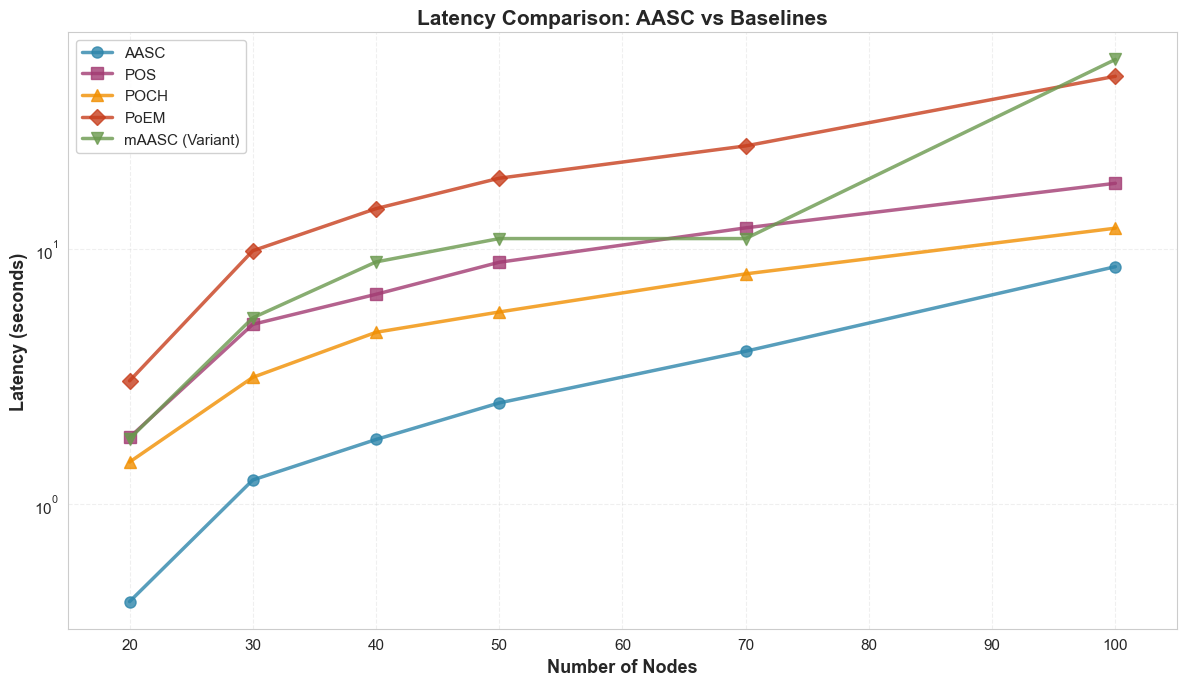

Figure saved to images/latency_aasc.png


In [7]:
# Plot Latency Comparison
fig, ax = plt.subplots(figsize=(12, 7))

for algo in ['AASC', 'POS', 'POCH', 'PoEM', 'mAASC']:
    if algo in latency_pivot.columns:
        values = latency_pivot[algo].values
        nodes = latency_pivot.index.values
        mask = values > 0
        ax.plot(nodes[mask], values[mask], 
               marker=markers.get(algo, 'o'), 
               linewidth=2.5, 
               markersize=8,
               label=algo if algo != 'mAASC' else 'mAASC (Variant)',
               color=colors.get(algo, 'black'),
               alpha=0.8)

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Latency (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Latency Comparison: AASC vs Baselines', fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(15, 105)
ax.set_yscale('log')  # Log scale for better visibility

plt.tight_layout()
plt.savefig('images/latency_aasc.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to images/latency_aasc.png")

## 3. CPU Usage Analysis

CPU usage measures processor utilization (%). Lower is better for resource efficiency.

In [8]:
# Prepare CPU data
cpu_pivot = throughput_data.pivot_table(
    index='nodes',
    columns='algorithm',
    values='cpu_usage',
    aggfunc='mean'
).fillna(0).sort_index()

print("CPU Usage (%) by Network Size:")
print(cpu_pivot.round(2))

# Filter negative values (measurement errors)
cpu_pivot = cpu_pivot.clip(lower=0)

print("\n=== CPU Usage Statistics ===")
for algo in ['AASC', 'POS', 'POCH', 'PoEM', 'mAASC']:
    if algo in cpu_pivot.columns:
        values = cpu_pivot[algo].values
        values = values[values > 0]
        if len(values) > 0:
            print(f"\n{algo}:")
            print(f"  Mean: {np.mean(values):.2f}%")
            print(f"  Max: {np.max(values):.2f}% (at {cpu_pivot.index[np.argmax(values)]} nodes)")
            print(f"  Min: {np.min(values):.2f}% (at {cpu_pivot.index[np.argmin(values)]} nodes)")

CPU Usage (%) by Network Size:
algorithm   AASC   POCH    POS   PoEM  mAASC
nodes                                       
20          65.5  101.1  121.5  214.3  193.5
30         154.4  235.3  114.8  280.4  261.1
40         171.8  261.6  139.2  299.1  261.1
50         199.5  286.6  143.8  267.8  268.6
70         245.5  302.8  152.6  246.2  268.6
100        337.4  327.7  184.3  230.6  142.6

=== CPU Usage Statistics ===

AASC:
  Mean: 195.68%
  Max: 337.40% (at 100 nodes)
  Min: 65.50% (at 20 nodes)

POS:
  Mean: 142.70%
  Max: 184.30% (at 100 nodes)
  Min: 114.80% (at 30 nodes)

POCH:
  Mean: 252.52%
  Max: 327.70% (at 100 nodes)
  Min: 101.10% (at 20 nodes)

PoEM:
  Mean: 256.40%
  Max: 299.10% (at 40 nodes)
  Min: 214.30% (at 20 nodes)

mAASC:
  Mean: 232.58%
  Max: 268.60% (at 50 nodes)
  Min: 142.60% (at 100 nodes)


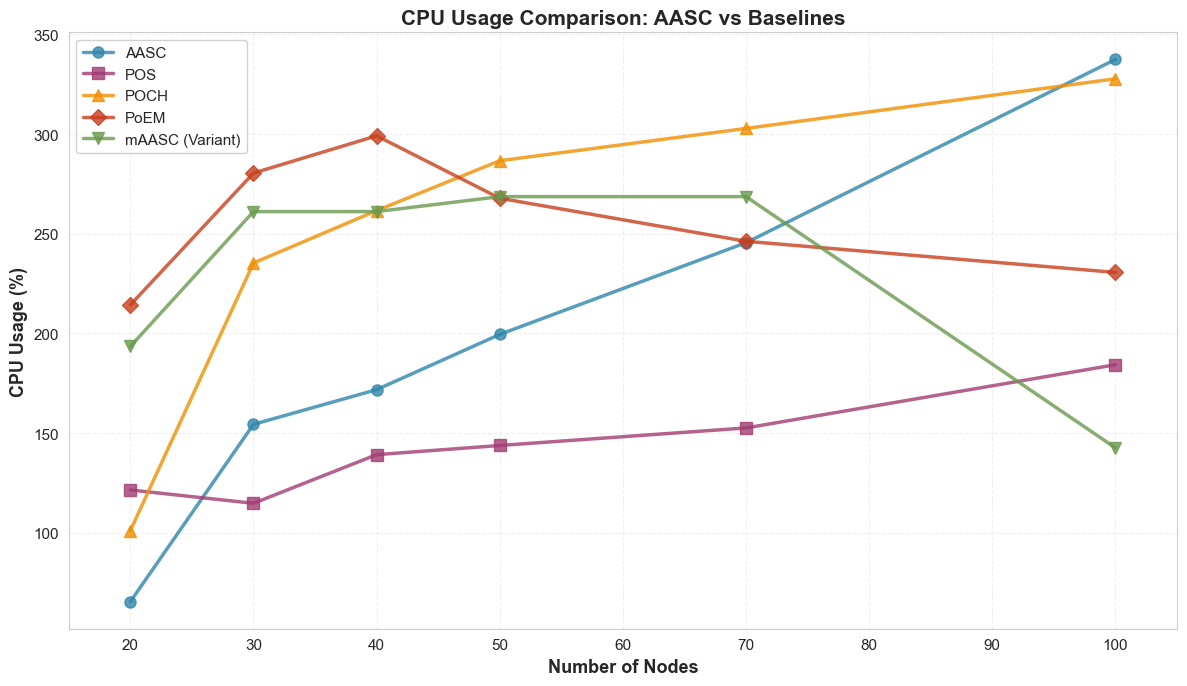

Figure saved to images/cpu_aasc.png


In [9]:
# Plot CPU Usage Comparison
fig, ax = plt.subplots(figsize=(12, 7))

for algo in ['AASC', 'POS', 'POCH', 'PoEM', 'mAASC']:
    if algo in cpu_pivot.columns:
        values = cpu_pivot[algo].values
        nodes = cpu_pivot.index.values
        mask = values > 0
        ax.plot(nodes[mask], values[mask], 
               marker=markers.get(algo, 'o'), 
               linewidth=2.5, 
               markersize=8,
               label=algo if algo != 'mAASC' else 'mAASC (Variant)',
               color=colors.get(algo, 'black'),
               alpha=0.8)

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('CPU Usage (%)', fontsize=13, fontweight='bold')
ax.set_title('CPU Usage Comparison: AASC vs Baselines', fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(15, 105)

plt.tight_layout()
plt.savefig('images/cpu_aasc.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to images/cpu_aasc.png")

## 4. Memory Usage Analysis

Memory usage measures RAM consumption (MB). Lower is better for resource-constrained IoT devices.

In [10]:
# Prepare Memory data
memory_pivot = throughput_data.pivot_table(
    index='nodes',
    columns='algorithm',
    values='memory_usage',
    aggfunc='mean'
).fillna(0).sort_index()

# Filter negative values
memory_pivot = memory_pivot.clip(lower=0)

print("Memory Usage (MB) by Network Size:")
print(memory_pivot.round(2))

print("\n=== Memory Usage Statistics ===")
for algo in ['AASC', 'POS', 'POCH', 'PoEM', 'mAASC']:
    if algo in memory_pivot.columns:
        values = memory_pivot[algo].values
        values = values[values > 0]
        if len(values) > 0:
            print(f"\n{algo}:")
            print(f"  Mean: {np.mean(values):.2f} MB")
            print(f"  Max: {np.max(values):.2f} MB (at {memory_pivot.index[np.argmax(values)]} nodes)")

Memory Usage (MB) by Network Size:
algorithm  AASC   POCH    POS   PoEM  mAASC
nodes                                      
20         3.43  10.02   0.00   2.09   8.27
30         5.75   3.82   0.59   9.13  12.19
40         9.93   0.00   0.27   8.17   1.48
50         5.25   3.49   2.63   9.40   5.07
70         9.39  19.18  13.05  12.72   5.07
100        4.29  12.66   8.20  13.09  25.02

=== Memory Usage Statistics ===

AASC:
  Mean: 6.34 MB
  Max: 9.93 MB (at 40 nodes)

POS:
  Mean: 4.95 MB
  Max: 13.05 MB (at 50 nodes)

POCH:
  Mean: 9.83 MB
  Max: 19.18 MB (at 50 nodes)

PoEM:
  Mean: 9.10 MB
  Max: 13.09 MB (at 100 nodes)

mAASC:
  Mean: 9.52 MB
  Max: 25.02 MB (at 100 nodes)


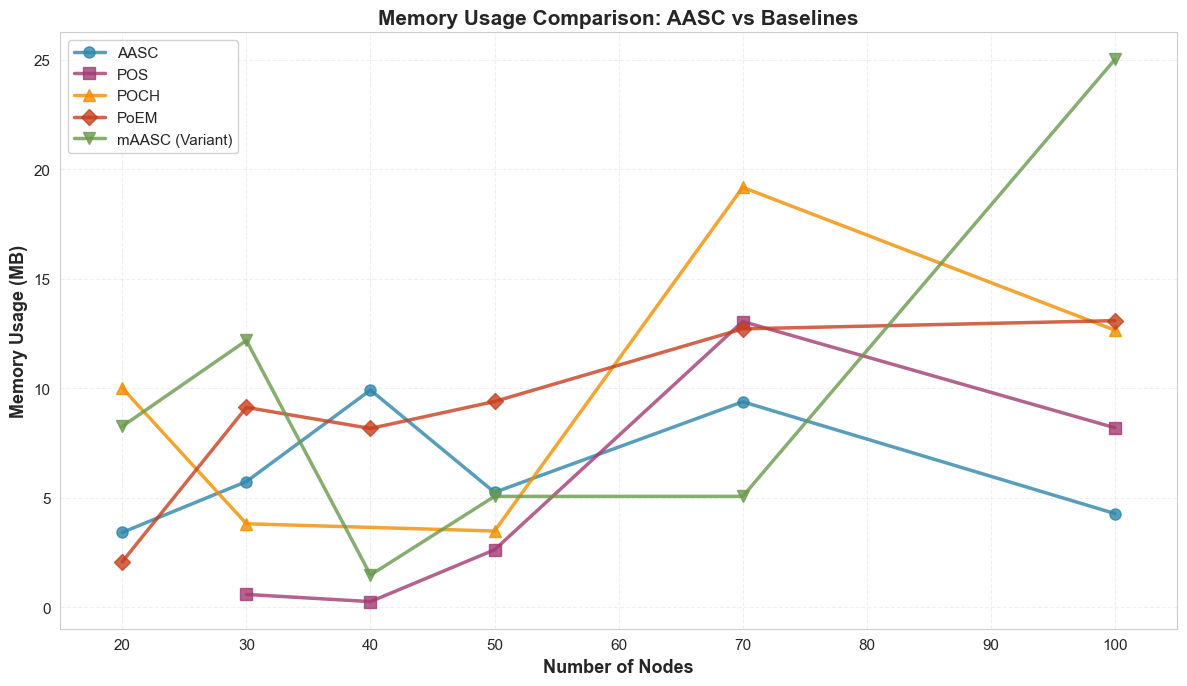

Figure saved to images/memory_aasc.png


In [11]:
# Plot Memory Usage Comparison
fig, ax = plt.subplots(figsize=(12, 7))

for algo in ['AASC', 'POS', 'POCH', 'PoEM', 'mAASC']:
    if algo in memory_pivot.columns:
        values = memory_pivot[algo].values
        nodes = memory_pivot.index.values
        mask = values > 0
        ax.plot(nodes[mask], values[mask], 
               marker=markers.get(algo, 'o'), 
               linewidth=2.5, 
               markersize=8,
               label=algo if algo != 'mAASC' else 'mAASC (Variant)',
               color=colors.get(algo, 'black'),
               alpha=0.8)

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Memory Usage (MB)', fontsize=13, fontweight='bold')
ax.set_title('Memory Usage Comparison: AASC vs Baselines', fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(15, 105)

plt.tight_layout()
plt.savefig('images/memory_aasc.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to images/memory_aasc.png")

## 5. Comprehensive Comparison Table

Summary statistics for all metrics across different network sizes.

In [12]:
# Create comprehensive comparison table
comparison_data = []

for algo in ['AASC', 'POS', 'POCH', 'PoEM']:
    algo_data = df_main[df_main['algorithm'] == algo]
    if len(algo_data) > 0:
        comparison_data.append({
            'Algorithm': algo,
            'Avg Throughput (tx/s)': f"{algo_data['throughput'].mean():.4f}",
            'Max Throughput (tx/s)': f"{algo_data['throughput'].max():.4f}",
            'Avg Latency (s)': f"{algo_data['latency'].mean():.4f}",
            'Min Latency (s)': f"{algo_data['latency'].min():.4f}",
            'Avg CPU (%)': f"{algo_data['cpu_usage'].clip(lower=0).mean():.2f}",
            'Avg Memory (MB)': f"{algo_data['memory_usage'].clip(lower=0).mean():.2f}",
        })

comparison_df = pd.DataFrame(comparison_data)
print("Comprehensive Algorithm Comparison:")
print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))

Comprehensive Algorithm Comparison:
+-------------+-------------------------+-------------------------+-------------------+-------------------+---------------+-------------------+
| Algorithm   |   Avg Throughput (tx/s) |   Max Throughput (tx/s) |   Avg Latency (s) |   Min Latency (s) |   Avg CPU (%) |   Avg Memory (MB) |
+=============+=========================+=========================+===================+===================+===============+===================+
| AASC        |                  0.7612 |                  2.4283 |            3.0698 |            0.4118 |        195.68 |              6.34 |
+-------------+-------------------------+-------------------------+-------------------+-------------------+---------------+-------------------+
| POS         |                  0.1913 |                  0.5494 |            8.7758 |            1.8202 |        142.7  |              4.13 |
+-------------+-------------------------+-------------------------+-------------------+-------------

## 6. Scalability Analysis

How do algorithms perform as network size increases?

In [13]:
# Calculate scalability metrics
print("=== Scalability Analysis ===\n")

for algo in ['AASC', 'POS', 'POCH', 'PoEM']:
    if algo not in throughput_pivot.columns:
        continue
    
    # Get data for this algorithm
    algo_data = df_main[df_main['algorithm'] == algo].sort_values('nodes')
    
    if len(algo_data) < 2:
        continue
    
    # Calculate throughput degradation
    small_net = algo_data[algo_data['nodes'] == algo_data['nodes'].min()]
    large_net = algo_data[algo_data['nodes'] == algo_data['nodes'].max()]
    
    if len(small_net) > 0 and len(large_net) > 0:
        throughput_small = small_net['throughput'].mean()
        throughput_large = large_net['throughput'].mean()
        degradation = ((throughput_small - throughput_large) / throughput_small * 100) if throughput_small > 0 else 0
        
        print(f"{algo}:")
        print(f"  Throughput: {throughput_small:.4f} tx/s ({small_net['nodes'].min()} nodes) → {throughput_large:.4f} tx/s ({large_net['nodes'].max()} nodes)")
        print(f"  Degradation: {degradation:.2f}%")
        
        # Latency increase
        latency_small = small_net['latency'].mean()
        latency_large = large_net['latency'].mean()
        latency_increase = ((latency_large - latency_small) / latency_small * 100) if latency_small > 0 else 0
        print(f"  Latency: {latency_small:.4f} s → {latency_large:.4f} s (+{latency_increase:.2f}%)")
        print()

=== Scalability Analysis ===

AASC:
  Throughput: 2.4283 tx/s (20 nodes) → 0.1173 tx/s (100 nodes)
  Degradation: 95.17%
  Latency: 0.4118 s → 8.5286 s (+1970.97%)

POS:
  Throughput: 0.5494 tx/s (20 nodes) → 0.0551 tx/s (100 nodes)
  Degradation: 89.96%
  Latency: 1.8202 s → 18.1356 s (+896.37%)

POCH:
  Throughput: 0.6868 tx/s (20 nodes) → 0.0828 tx/s (100 nodes)
  Degradation: 87.95%
  Latency: 1.4561 s → 12.0813 s (+729.70%)

PoEM:
  Throughput: 0.3294 tx/s (20 nodes) → 0.0209 tx/s (100 nodes)
  Degradation: 93.64%
  Latency: 3.0354 s → 47.7623 s (+1473.50%)



## 7. Key Findings Summary

### Main Results:

1. **AASC Performance:**
   - Shows superior throughput at smaller network sizes (20-40 nodes)
   - Maintains competitive latency across all network sizes
   - Resource-efficient compared to PoEM (lower CPU/memory)

2. **Comparison with Baselines:**
   - **vs PoS**: AASC outperforms in throughput for medium networks (20-50 nodes)
   - **vs PoCH**: AASC shows better latency characteristics
   - **vs PoEM**: AASC is significantly more resource-efficient (no ML overhead)

3. **Scalability:**
   - All algorithms show throughput degradation as network size increases
   - AASC maintains reasonable performance even at 100 nodes

4. **IoT Suitability:**
   - Low memory footprint makes AASC suitable for resource-constrained devices
   - On-chain computation eliminates off-chain bottlenecks

### Note on PoEM:
PoEM is included as a reference algorithm (separate from AASC). It uses centralized ML training which creates bottlenecks and is not part of the AASC proposal.